In [1]:
import rich
import logging
import glob
import matplotlib.pyplot as plt
import time
import re
import os
import awkward as ak
import numpy as np
import pandas as pd
import json 
import yaml

import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from pathlib import Path
from collections import defaultdict
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch
import matplotlib as mpl
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)

# functions


In [2]:
import numpy as np

def estimate_active_time(df, max_gap=60):
    timestamps = np.sort(
        df["timestamp"].dropna().to_numpy()
    )

    dt = np.diff(timestamps)

    # Somma soltanto gli intervalli inferiori alla soglia
    return dt[dt <= max_gap].sum()

In [3]:
def subtract_background(
    energy_data,
    energy_background,
    bin_edges,
    alpha
):
    counts_data, _ = np.histogram(
        energy_data,
        bins=bin_edges
    )

    counts_background, _ = np.histogram(
        energy_background,
        bins=bin_edges
    )

    counts_background_scaled = alpha * counts_background

    counts_net = (
        counts_data
        - counts_background_scaled
    )

    # Incertezza statistica sulla sottrazione
    errors_net = np.sqrt(
        counts_data
        + alpha**2 * counts_background
    )

    return {
        "data": counts_data,
        "background": counts_background,
        "background_scaled": counts_background_scaled,
        "net": counts_net,
        "error": errors_net
    }

In [4]:


def generic_polycone_profile(solid):
    r = np.asarray(
        solid.evaluateParameterWithUnits("pR"),
        dtype=float
    )
    z = np.asarray(
        solid.evaluateParameterWithUnits("pZ"),
        dtype=float
    )

    return np.append(r, r[0]), np.append(z, z[0])


def polycone_profile(solid):
    z = np.asarray(
        solid.evaluateParameterWithUnits("pZpl"),
        dtype=float
    )
    rmin = np.asarray(
        solid.evaluateParameterWithUnits("pRMin"),
        dtype=float
    )
    rmax = np.asarray(
        solid.evaluateParameterWithUnits("pRMax"),
        dtype=float
    )

    r = np.concatenate([rmax, rmin[::-1], [rmax[0]]])
    z = np.concatenate([z, z[::-1], [z[0]]])

    return r, z

    
def get_profile(solid):
    solid_type = str(solid.type).lower()

    if "genericpolycone" in solid_type:
        return generic_polycone_profile(solid)

    if "polycone" in solid_type:
        return polycone_profile(solid)

    if "tubs" in solid_type or "tube" in solid_type:
        return tubs_profile(solid)

    if "box" in solid_type:
        return box_profile(solid)

    raise TypeError(
        f"Solido {solid.name} di tipo {solid.type} non supportato"
    )

def evaluate_vector(vector):
    """Converte Position o Rotation di pyg4ometry in array numerico."""
    return np.asarray(vector.eval(), dtype=float)


def physical_volume_matrix(pv):
    """Matrice omogenea della trasformazione del PhysicalVolume."""
    position = evaluate_vector(pv.position)
    rotation = evaluate_vector(pv.rotation)

    rotation_matrix = np.linalg.inv(
        pg4.transformation.tbxyz2matrix(rotation)
    )

    matrix = np.eye(4)
    matrix[:3, :3] = rotation_matrix
    matrix[:3, 3] = position

    return matrix


def collect_global_placements(logical_volume, parent_matrix=None):
    """
    Percorre ricorsivamente il GDML e restituisce la trasformazione
    globale di ogni volume fisico.
    """
    if parent_matrix is None:
        parent_matrix = np.eye(4)

    placements = {}

    def walk(mother_lv, mother_matrix):
        for pv in mother_lv.daughterVolumes:
            local_matrix = physical_volume_matrix(pv)
            global_matrix = mother_matrix @ local_matrix

            logical_name = pv.logicalVolume.name

            placements.setdefault(logical_name, []).append({
                "physical_name": pv.name,
                "logical_volume": pv.logicalVolume,
                "matrix": global_matrix,
            })

            walk(pv.logicalVolume, global_matrix)

    walk(logical_volume, parent_matrix)

    return placements


def find_germanium_detector(reg):
    candidates = []

    for name, lv in reg.logicalVolumeDict.items():
        material_name = getattr(lv.material, "name", str(lv.material))

        if "Germanium" in material_name:
            candidates.append(name)

    if len(candidates) == 0:
        raise ValueError("Nessun detector al germanio trovato")

    if len(candidates) > 1:
        print("Detector al germanio trovati:", candidates)

    return candidates[0]



def find_source(reg):
    candidates = []

    for name, lv in reg.logicalVolumeDict.items():
        material_name = getattr(lv.material, "name", str(lv.material))

        if "Source" in material_name:
            candidates.append(name)

    if len(candidates) == 0:
        raise ValueError("Nessuna sorgente trovate")

    if len(candidates) > 1:
        print("Sorgente trovata:", candidates)

    return candidates[0]

def tubs_profile(solid):
    """Profilo r-z di un cilindro Tubs."""

    rmin = float(solid.evaluateParameterWithUnits("pRMin"))
    rmax = float(solid.evaluateParameterWithUnits("pRMax"))
    dz = float(solid.evaluateParameterWithUnits("pDz"))

    # pDz è la lunghezza totale lungo z
    zmin = -dz / 2
    zmax = dz / 2

    r = np.array([
        rmin,
        rmax,
        rmax,
        rmin,
        rmin
    ])

    z = np.array([
        zmin,
        zmin,
        zmax,
        zmax,
        zmin
    ])

    return r, z

def box_profile(solid):
    """Profilo nel piano locale x-z di un Box."""

    size_x = float(solid.evaluateParameterWithUnits("pX"))
    size_z = float(solid.evaluateParameterWithUnits("pZ"))

    xmin = -size_x / 2
    xmax = size_x / 2
    zmin = -size_z / 2
    zmax = size_z / 2

    r = np.array([
        xmin,
        xmax,
        xmax,
        xmin,
        xmin
    ])

    z = np.array([
        zmin,
        zmin,
        zmax,
        zmax,
        zmin
    ])

    return r, z

def transform_profile(r, z, matrix):
    """
    Trasforma un profilo locale (r, z) nelle coordinate globali.

    Parameters
    ----------
    r : array-like
        Coordinate radiali locali.
    z : array-like
        Coordinate verticali locali.
    matrix : array-like, shape (4, 4)
        Matrice omogenea contenente rotazione e traslazione globali.

    Returns
    -------
    radius : ndarray
        Distanza globale dall'asse z.
    height : ndarray
        Coordinata z globale.
    """

    r = np.asarray(r, dtype=float)
    z = np.asarray(z, dtype=float)

    # Punti omogenei locali: (x=r, y=0, z, 1)
    points = np.column_stack([
        r,
        np.zeros_like(r),
        z,
        np.ones_like(r)
    ])

    # Trasformazione nelle coordinate globali
    transformed = (matrix @ points.T).T

    x_global = transformed[:, 0]
    y_global = transformed[:, 1]
    z_global = transformed[:, 2]

    radius = np.sqrt(x_global**2 + y_global**2)
    height = z_global

    return radius, height

# Soimulation

In [5]:
import dbetto
import pygeomhades
import pygeomtools
from pygeomtools import write_pygeom
import pyg4ometry as pg4
from pyg4ometry import gdml
import lh5
import os
import numpy as np
import matplotlib.pyplot as plt

In [6]:
detector = "V03422A"
measure = "th_HS2_top_psa"
N_sim = int(1e6)

In [15]:
#  generazione file GDLM
'''metadata_path = "/global/u2/r/ritaferi/HADES_DATA/hades-metadata"
db = dbetto.TextDB(metadata_path)

configuration = (
    db.hardware.configuration[detector]
    ["c1"]
    [measure]
    ["run0001"]
)

reg = pygeomhades.core.construct(configuration)'''

'metadata_path = "/global/u2/r/ritaferi/HADES_DATA/hades-metadata"\ndb = dbetto.TextDB(metadata_path)\n\nconfiguration = (\n    db.hardware.configuration[detector]\n    ["c1"]\n    [measure]\n    ["run0001"]\n)\n\nreg = pygeomhades.core.construct(configuration)'

In [16]:
'''
output_dir = f"/global/u2/r/ritaferi/HADES_DATA/"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(
    output_dir,
    f"{detector}_{measure}_run0001.gdml"
)

write_pygeom(reg, output_file)

print(f"File GDML creato: {output_file}")'''

'\noutput_dir = f"/global/u2/r/ritaferi/HADES_DATA/"\nos.makedirs(output_dir, exist_ok=True)\n\noutput_file = os.path.join(\n    output_dir,\n    f"{detector}_{measure}_run0001.gdml"\n)\n\nwrite_pygeom(reg, output_file)\n\nprint(f"File GDML creato: {output_file}")'

In [19]:
gdml_file = "/global/u2/r/ritaferi/HADES_DATA/V03422A_th_HS2_top_psa_run0001.gdml"

reader = pg4.gdml.Reader(gdml_file)
reg = reader.getRegistry()

Summary:pyg4ometry.gdml.Reader:Reader.load>


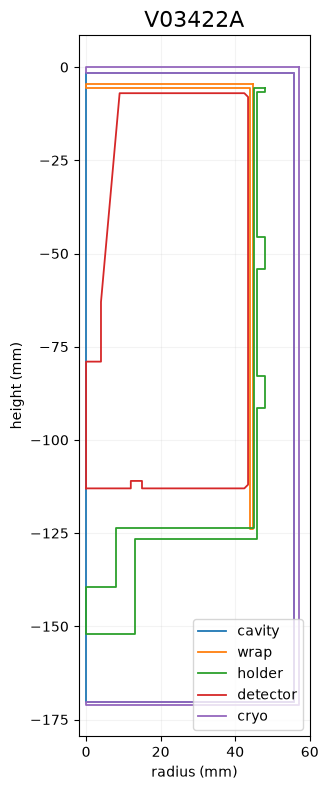

In [20]:
placements = collect_global_placements(reg.getWorldVolume())

detector_name = find_germanium_detector(reg)

components = {
    "cavity_lv": {
        "label": "cavity",
        "color": "tab:blue"
    },
    "Wrap": {
        "label": "wrap",
        "color": "tab:orange"
    },
    "Holder": {
        "label": "holder",
        "color": "tab:green"
    },
    detector_name: {
        "label": "detector",
        "color": "tab:red"
    },
    "Cryostat": {
        "label": "cryo",
        "color": "tab:purple"
    },
}

fig, ax = plt.subplots(figsize=(5, 8))

for logical_name, style in components.items():

    if logical_name not in placements:
        print(f"Volume non trovato: {logical_name}")
        continue

    # Se esistono più copie, le disegna tutte
    for index, placement in enumerate(placements[logical_name]):

        lv = placement["logical_volume"]
        matrix = placement["matrix"]

        try:
            r_local, z_local = get_profile(lv.solid)
        except TypeError as error:
            print(error)
            continue

        radius, height = transform_profile(
            r_local,
            z_local,
            matrix
        )

        # Una sola voce in legenda per componente
        label = style["label"] if index == 0 else None

        ax.plot(
            radius,
            height,
            color=style["color"],
            linewidth=1.3,
            label=label
        )

ax.set_title(detector_name, fontsize=16)
ax.set_xlabel("radius (mm)")
ax.set_ylabel("height (mm)")

ax.set_xlim(left=-2)
ax.set_aspect("equal", adjustable="box")

ax.grid(alpha=0.15)
ax.legend(loc = 'lower right')

plt.tight_layout()
plt.show()

In [10]:
# simulazione vera e propria

import awkward as ak
import hist
import matplotlib.pyplot as plt
import h5py
import glob
import numpy as np

from remage import remage_run
import lh5

In [21]:
N_sim = 50

In [22]:
macro = [
    "/RMG/Manager/Logging/LogLevel summary",

    "/RMG/Processes/HadronicPhysics Shielding",

    f"/RMG/Geometry/RegisterDetector Germanium {detector} 1",

    "/RMG/Output/NtupleUseVolumeName true",
    "/RMG/Output/NtuplePerDetector false",

    "/run/initialize",

    # Generatore confinato nel materiale attivo della sorgente
    "/RMG/Generator/Confine Volume",
    "/RMG/Generator/Confinement/Physical/AddVolume Source_PV",

    "/RMG/Generator/Select GPS",

    # CAMBIA QUI LO IONE -->thorio228
    "/gps/particle ion",
    "/gps/ion 90 228",
    "/gps/energy 0 keV",

    # Numero di nuclei
    f"/run/beamOn {N_sim}",
]

try:
    remage_run(
        macros=macro,
        gdml_files=f"V03422A_th_HS2_top_psa_run0001.gdml",
        output=f"{detector}_{measure}_run0001.lh5",
        overwrite_output=True
    )

    print("✅ Simulazione completata")

except Exception as e:
    print(f"❌ Simulazione fallita: {e}")



  _ __ ___ _ __ ___   __ _  __ _  ___ 
 | '__/ _ \ '_ ` _ \ / _` |/ _` |/ _ \
 | | |  __/ | | | | | (_| | (_| |  __/ v1.1.0
 |_|  \___|_| |_| |_|\__,_|\__, |\___| using geant4-11-03-patch-02 [MT]
                           |___/      

G4GDML: Reading 'V03422A_th_HS2_top_psa_run0001.gdml'...
G4GDML: Reading definitions...
G4GDML: Reading materials...
G4GDML: Reading solids...
G4GDML: Reading structure...
G4GDML: Reading userinfo...
G4GDML: Reading setup...
G4GDML: Reading 'V03422A_th_HS2_top_psa_run0001.gdml' done!
Stripping off GDML names of materials, solids and volumes ...

-------- WWWW ------- G4Exception-START -------- WWWW -------
*** G4Exception : GeomVol1002
      issued by : G4PVPlacement::CheckOverlaps()
Overlap with volume already placed !
          Overlap is detected for volume cavity_pv:0 (G4GenericPolycone) with source_holder_pv_1:0 (G4Polycone)
          overlap at local point (-52.1798,-5.97918,41) by 1.47875 mm  (max of 43 cases)
NOTE: Reached maximum fixed number -1

[Summary -> CLHEP::HepRandom seed changed to: 642959554 (from system entropy)
[Summary -> Checking for overlaps in GDML geometry...
[Summary -> Opening output file: .rmg-tmp-61368.V03422A_th_HS2_top_psa_run0001.hdf5 (for V03422A_th_HS2_top_psa_run0001.lh5)
[Summary -> Starting run nr. 0. Current local time is 23-09-2026 01:34:43 PDT
[Summary -> Number of events to be processed: 50
[Summary -> Run nr. 0 completed. 50 events simulated. Current local time is 23-09-2026 01:34:43 PDT
[Summary -> Stats: run time was 0 days, 0 hours, 0 minutes and 0 seconds
[Summary -> Stats: average event processing time was 0.001207 seconds/event = 828.49 events/second
[Summary -> Stats: Event processing time might be inaccurate
[Summary -> Stats: on average, 0.0 iterations were needed to sample a valid vertex (100.0% efficiency)
[Summary -> Stats: average time to sample a vertex was 3.47300 us/event
[Summary -> Reshaping output files
[Summary -> processing .V03422A_th_HS2_top_psa_run0001.lh5 -> V03422A_th_

✅ Simulazione completata


In [12]:
filename = f"{detector}_{measure}_run0001.lh5"

In [ ]:
# post processing

import reboost
from reboost import hpge
from reboost.hpge import surface, psd
from reboost.shape import group
from reboost.math import functions
from reboost.math.stats import gaussian_sample
from reboost.utils import get_remage_detector_uids






In [14]:
data = lh5.read_as(
    "stp/germanium",
    filename,
    "ak"
)


KeyboardInterrupt: 

In [ ]:
energy = ak.to_numpy(
    ak.sum(data.edep, axis=-1)
)

energy_smeared = reboost.math.stats.gaussian_sample(energy, sigma=1)

In [ ]:
# Impostazioni istogramma
bin_width = 10       # keV
energy_max = 3500   # keV
bins = int(energy_max / bin_width)


plt.hist(energy, bins =bins, color = 'navy', label = 'theory')
plt.hist(energy_smeared, bins =bins, histtype = 'step',  color = 'deepskyblue', label = 'smeared')


plt.xlabel("Energia depositata [keV]")
plt.ylabel(f"Conteggi / {bin_width} keV")
plt.yscale("log")
plt.grid(alpha=0.25)
plt.legend()
plt.xlim(0, energy_max)
plt.tight_layout()
plt.show()

# data

In [ ]:
detector = "V03422A"
run = "r001"
version = "v1.2.1"

measurement_files = sorted(glob.glob(
    #f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.1.0/generated/tier/hit/{detector}/c1/*"
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}//generated/tier/hit/{detector}/c1/*"
))

print(*measurement_files, sep="\n")

In [ ]:
measurements = [
    os.path.basename(path)
    for path in measurement_files
]

print(measurements)

In [ ]:
measure = "th_HS2_top_psa"

In [ ]:
file_names = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}//generated/tier/hit/{detector}/c1/{measure}/char_data-{detector}-{measure}-*.lh5"
))
file_names_bkg = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}/generated/tier/hit/{detector}/c1/bkg/char_data-{detector}-bkg-r001-*.lh5"
    #f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.1.0/generated/tier/hit/V03422A/c1/bkg"
))

In [ ]:
len(file_names)

In [ ]:
bkg = lh5.read("hit", file_names_bkg)

In [ ]:
data = lh5.read("hit", file_names)

In [ ]:
df_bkg =  bkg.view_as("pd") 
df = data.view_as("pd")
df.head()

In [ ]:
import pandas as pd

times = {}

for name, dataframe in [
    ("Misura", df),
    ("Background", df_bkg)
]:
    ts = dataframe["timestamp"].dropna()

    start_time = ts.min()
    stop_time = ts.max()
    elapsed_time = stop_time - start_time

    times[name] = {
        "start": start_time,
        "stop": stop_time,
        "elapsed": elapsed_time
    }

    print(f"\n{name}")
    print("Numero eventi:", len(ts))
    print(
        "Inizio:",
        pd.to_datetime(start_time, unit="s", utc=True)
    )
    print(
        "Fine:",
        pd.to_datetime(stop_time, unit="s", utc=True)
    )
    print(f"Intervallo totale: {elapsed_time:.2f} s")
    print(f"Intervallo totale: {elapsed_time / 3600:.4f} h")


# Tempo della misura: acquisizione continua
time_measurement = times["Misura"]["elapsed"]

# Tempo attivo del background, escludendo le interruzioni
time_background = times["Background"]["elapsed"]

# Fattore di normalizzazione del background
alpha = time_measurement / time_background

print("\nNormalizzazione")
print(f"Tempo misura: {time_measurement:.2f} s")
print(f"Tempo background: {time_background:.2f} s")
print(f"Alpha: {alpha:.6f}")

In [ ]:
E_noQC = df["cuspEmax_ctc_cal"]

mask_clean = (
    ~df["is_discharge"]
    & df["is_positive_polarity_candidate"]
)

mask_highPSD = (
    mask_clean
    & df["AoE_High_Side_Cut"]
)

mask_PSD = (
    mask_clean
    & df["AoE_Double_Sided_Cut"]
)

mask_noPSD = (
    mask_clean
    & ~df["AoE_Double_Sided_Cut"]
)


# Background: stesse selezioni applicate ai dati
mask_bkg = (
    ~df_bkg["is_discharge"]
    & df_bkg["is_positive_polarity_candidate"]
)

mask_PSD_bkg = (
    mask_bkg
    & df_bkg["AoE_Double_Sided_Cut"]
)


E = df.loc[
    mask_clean,
    "cuspEmax_ctc_cal"
]

E_bkg = df_bkg.loc[
    mask_bkg,
    "cuspEmax_ctc_cal"
]

E_PSD = df.loc[
    mask_PSD,
    "cuspEmax_ctc_cal"
]

E_PSD_bkg = df_bkg.loc[
    mask_PSD_bkg,
    "cuspEmax_ctc_cal"
]


In [ ]:
emin = 500
emax = 3500
bins = 350

# Bordi comuni
bin_edges = np.linspace(
    emin,
    emax,
    bins + 1
)


# --------------------------------------------------
# DATI DOPO QC
# --------------------------------------------------

counts_data, _ = np.histogram(
    E,
    bins=bin_edges
)


# --------------------------------------------------
# BACKGROUND DOPO QC
# --------------------------------------------------

counts_bkg, _ = np.histogram(
    E_bkg,
    bins=bin_edges
)

counts_bkg_scaled = (
    alpha * counts_bkg
)

counts_net = (
    counts_data
    - counts_bkg_scaled
)


# --------------------------------------------------
# DATI DOPO PSD
# --------------------------------------------------

counts_PSD, _ = np.histogram(
    E_PSD,
    bins=bin_edges
)


# --------------------------------------------------
# BACKGROUND DOPO PSD
# --------------------------------------------------

counts_PSD_bkg, _ = np.histogram(
    E_PSD_bkg,
    bins=bin_edges
)

counts_PSD_bkg_scaled = (
    alpha * counts_PSD_bkg
)

counts_PSD_net = (
    counts_PSD
    - counts_PSD_bkg_scaled
)


# --------------------------------------------------
# RIEPILOGO
# --------------------------------------------------

print("Conteggi dati:", counts_data.sum())
print("Conteggi background:", counts_bkg.sum())
print(
    "Conteggi background normalizzati:",
    counts_bkg_scaled.sum()
)
print(
    "Conteggi netti:",
    counts_net.sum()
)

print("\nConteggi dati dopo PSD:", counts_PSD.sum())
print(
    "Conteggi background dopo PSD:",
    counts_PSD_bkg.sum()
)
print(
    "Conteggi background normalizzati dopo PSD:",
    counts_PSD_bkg_scaled.sum()
)
print(
    "Conteggi netti dopo PSD:",
    counts_PSD_net.sum()
)

In [ ]:
# Bordi comuni a tutti gli istogrammi
bin_edges = np.linspace(
    emin,
    emax,
    bins + 1
)

# Plot
plt.figure(figsize=(10, 3))

# Dati dopo QC, senza sottrazione
plt.stairs(
    counts_data,
    bin_edges,
    fill=True,
    color="deepskyblue",
    label="Data"
)

# Dati dopo PSD, senza sottrazione
plt.stairs(
    counts_PSD,
    bin_edges,
    fill = True,
    color="orange",
    #linewidth=1.2,
    label="Data after A/E"
)

plt.stairs(counts_bkg_scaled,
          bin_edges,
          color = 'green',
          label = 'scaled background')

# Dati dopo QC, con background sottratto
plt.stairs(
    counts_net,
    bin_edges,
    color="navy",
    #linewidth=1.2,
    label="Data − background"
)

# Dati dopo PSD, con background sottratto
plt.stairs(
    counts_PSD_net,
    bin_edges,
    color="red",
    #linewidth=1.2,
    label="After A/E − background"
)

plt.axhline(
    0,
    color="black",
    linewidth=0.8
)

plt.xlim(emin, emax)
plt.yscale('log')
plt.ylim(1e-2, 4e5)

plt.title(f"{detector}: {measure}")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
time_measurement

In [ ]:
time_measurement2 = 5 * 3600
time_measurement2

# confronto dati e simulazione

In [ ]:
activity = 87e3       # Bq
N_sim = 1_000_000     # numero di decadimenti generati in REMAGE

N_real = activity * time_measurement
weight = N_real / N_sim

print(f"Tempo misura: {time_measurement} s")
print(f"Decadimenti reali: {N_real:.3e}")
print(f"Decadimenti simulati: {N_sim:.3e}")
print(f"Peso MC: {weight}")

counts_MC_sclaed, _ = np.histogram(
    energy_smeared,
    bins=bins,
    weights = np.full(len(energy_smeared), weight),
)

#counts_MC_scaled = counts_MC * weight


In [ ]:
w = np.array(len(counts_MC), weight) 
w

In [ ]:
plt.figure(figsize=(8, 3))
plt.hist(energy_smeared, bins =bin_edges[:-1], weights = np.full(len(energy_smeared), weight),  color = 'navy', label = 'theory')
plt.stairs(
    counts_data,
    bin_edges,
    color="deepskyblue",
    label="Data"
)

plt.stairs(
    counts_MC,
    bin_edges,
    color="green",
    label="MC normalized"
)

plt.xlim(emin, emax)
plt.yscale("log")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("time_measurement =", time_measurement)
print("activity =", activity)
print("N_real =", N_real)
print("N_sim =", N_sim)
print("weight =", weight)

print("len energy_smeared =", len(energy_smeared))
print("MC raw counts =", np.sum(counts_MC))
print("MC scaled counts =", np.sum(counts_MC * weight))
print("Data counts =", np.sum(counts_data))